In [1]:
# Import libraries, load saved models

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from sklearn.metrics import mean_absolute_error, r2_score

MODEL_DIR = "../../ml-service/models"
FEATURES_PATH = "../../datasets/processed/features.csv"

reg = joblib.load(f"{MODEL_DIR}/aqi_regressor.joblib")
feature_cols = joblib.load(f"{MODEL_DIR}/feature_columns.joblib")

df = pd.read_csv(FEATURES_PATH)
df['datetimeLocal'] = pd.to_datetime(df['datetimeLocal'])
df = df.sort_values('datetimeLocal').reset_index(drop=True)
df.shape

c:\Users\KIIT0001\miniconda3\envs\ml-env\Lib\pickle.py:1718: UserWarning: [02:44:47] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\gbm\../common/error_msg.h:83: If you are loading a serialized model (like pickle in Python, RDS in R) or
configuration generated by an older version of XGBoost, please export the model by calling
`Booster.save_model` from that version first, then load it back in current version. See:

    https://xgboost.readthedocs.io/en/stable/tutorials/saving_model.html

for more details about differences between saving model and serializing.

  setstate(state)


(6190, 65)

In [2]:
# Simulate different air pollution scenarios by adjusting lag and rolling PM2.5 features, then measure the impact on average model predictions.

baseline = df.sample(500, random_state=42).copy()
scenarios = {}

for pct in [-30, -15, 0, 15, 30, 50]:
    scenario_df = baseline.copy()
    factor = 1 + pct / 100
    scenario_df['pm25_lag1'] = scenario_df['pm25_lag1'] * factor
    scenario_df['pm25_roll6_mean'] = scenario_df['pm25_roll6_mean'] * factor
    preds = reg.predict(scenario_df[feature_cols])
    scenarios[pct] = preds.mean()

scenario_series = pd.Series(scenarios).sort_index()
scenario_series

-30    85.304253
-15    85.655586
 0     86.120842
 15    86.705704
 30    87.249641
 50    87.984894
dtype: float32

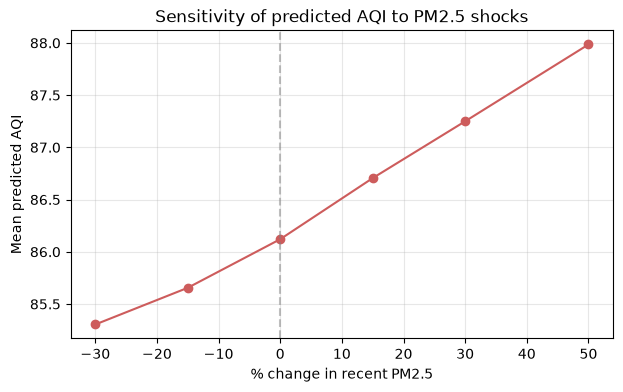

In [3]:
plt.figure(figsize=(7, 4))
scenario_series.plot(marker='o', color='indianred')
plt.axvline(0, color='gray', linestyle='--', alpha=0.5)
plt.xlabel('% change in recent PM2.5')
plt.ylabel('Mean predicted AQI')
plt.title('Sensitivity of predicted AQI to PM2.5 shocks')
plt.grid(True, alpha=0.3)
plt.show()

In [4]:
# Scenario simulation - combined pollutant spike 

spike_df = baseline.copy()
for col in ['pm25_lag1', 'pm25_roll6_mean', 'pm10_lag1', 'pm10_roll6_mean', 'no2_lag1', 'no2_roll6_mean']:
    spike_df[col] = spike_df[col] * 1.4  # +40% combined spike

baseline_pred = reg.predict(baseline[feature_cols])
spike_pred = reg.predict(spike_df[feature_cols])

print(f"Baseline mean predicted AQI: {baseline_pred.mean():.1f}")
print(f"Spike scenario mean predicted AQI: {spike_pred.mean():.1f}")
print(f"Average increase: {(spike_pred - baseline_pred).mean():.1f} AQI points")

Baseline mean predicted AQI: 86.1
Spike scenario mean predicted AQI: 87.8
Average increase: 1.7 AQI points


In [5]:
# Robustness testing across different time windows

df['month_name'] = df['datetimeLocal'].dt.strftime('%Y-%m')
df['pred'] = reg.predict(df[feature_cols])

monthly_perf = df.groupby('month_name').apply(
    lambda g: pd.Series({
        'MAE': mean_absolute_error(g['AQI'], g['pred']),
        'R2': r2_score(g['AQI'], g['pred']) if g['AQI'].nunique() > 1 else np.nan,
        'n_rows': len(g),
    }),include_groups=False)
monthly_perf

,MAE,R2,n_rows
month_name,,,
2022-01,2.731959,0.996164,799.0
2022-02,2.061272,0.989291,310.0
2022-03,1.246798,0.994501,619.0
2022-04,1.758060,0.979206,3764.0
2022-05,2.316907,0.927773,698.0


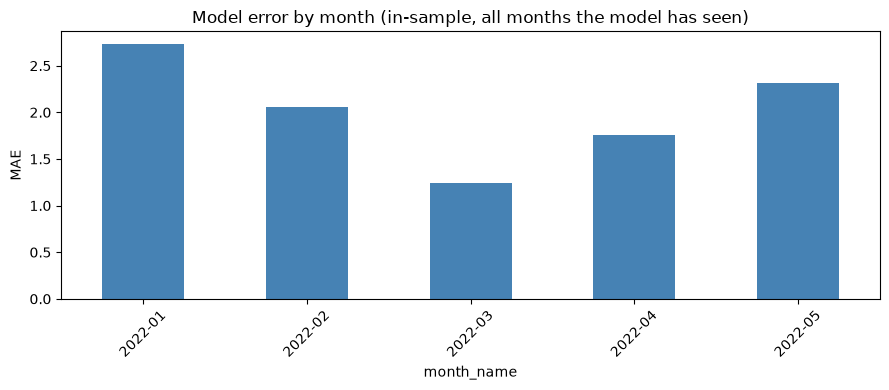

In [6]:
fig, ax1 = plt.subplots(figsize=(9, 4))
monthly_perf['MAE'].plot(kind='bar', ax=ax1, color='steelblue')
ax1.set_ylabel('MAE')
ax1.set_title('Model error by month (in-sample, all months the model has seen)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()